Multivariate Linear Regression

$$f(x) = w_1*x_1^2 + w_2*x_2 + b

In [310]:
import numpy as np
import matplotlib.pyplot as plt

In [311]:
num_points = 500
w = np.random.normal(0, 5, size=2)
b = np.random.normal(0, 10)
noise  = np.random.normal(0, 1, num_points)

In [312]:
x1 = np.random.uniform(-5, 5, num_points)
x2 = np.random.uniform(-5, 5, num_points)
X = np.column_stack([x1, x2])

In [313]:
X.shape

(500, 2)

In [314]:
Phi = np.column_stack([X[:,0]**2, X[:,1]])
Phi.shape

(500, 2)

In [315]:
def f(X, w, b):
    return (w[0] * X[:, 0]) + (w[1] * X[:,1]) + b

In [316]:
y = f(Phi, w, b) + noise
y.shape

(500,)

In [317]:
def train_test_split_numpy(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    indices = np.random.permutation(len(X))
    
    test_samples = int(len(X) * test_size)
    train_indices = indices[test_samples:]
    test_indices = indices[:test_samples]
    
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [318]:
X_train, X_test, y_train, y_test = train_test_split_numpy(Phi, y, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (400, 2) (400,)
Test shapes: (100, 2) (100,)


Compute cost

In [319]:
def compute_cost(X, y, w, b):
    m = X.shape[0] 
    predictions = f(X, w, b)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [320]:
compute_cost(X_train, y_train, w, b)

np.float64(0.5858238211869183)

Derivatives

In [321]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    error = (f(X, w, b) - y)
    dw = (1 / m) * error @ X
    db = (1 / m) * np.sum(error)
    return dw, db

Gradient Descent

In [322]:
num_iterations = 2000
learning_rate = 0.0001

In [323]:
def compute_descent(X, y, w, b, num_iterations, learning_rate):
    cost_history = []
    
    for i in range(num_iterations):
        dw, db = compute_gradients(X, y, w, b)
        
        w -= learning_rate * dw
        b -= learning_rate * db
        
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")
    
    return w, b, cost_history

Hyper parameter Tuning

In [324]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


In [325]:
rates = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10]
results = {}

for lr in rates:
    w_trial = np.zeros(2)
    b_trial = 0.0

    w_final, b_final, cost_history = compute_descent(
        X_train_scaled, y_train, w_trial, b_trial, num_iterations=1000, learning_rate=lr
    )

    results[lr] = cost_history[-1]
    print(f"LR: {lr} | Final Cost: {results[lr]:.4f}")

finite_results = {lr: c for lr, c in results.items() if np.isfinite(c)}
best_lr = min(finite_results, key=finite_results.get)
print(f"\nBest Learning Rate: {best_lr}")

Iteration 0: Cost 194.9684152702076
Iteration 100: Cost 0.5815574727013597
Iteration 200: Cost 0.5815573298263393
Iteration 300: Cost 0.5815573298263393
Iteration 400: Cost 0.5815573298263393
Iteration 500: Cost 0.5815573298263393
Iteration 600: Cost 0.5815573298263393
Iteration 700: Cost 0.5815573298263393
Iteration 800: Cost 0.5815573298263393
Iteration 900: Cost 0.5815573298263393
LR: 0.1 | Final Cost: 0.5816
Iteration 0: Cost 235.79514422548317
Iteration 100: Cost 32.09869135788374
Iteration 200: Cost 4.807644086008906
Iteration 300: Cost 1.1486287745518327
Iteration 400: Cost 0.6577030328710641
Iteration 500: Cost 0.5917893669615921
Iteration 600: Cost 0.582933236527844
Iteration 700: Cost 0.5817424813825033
Iteration 800: Cost 0.5815822630717952
Iteration 900: Cost 0.5815606898714202
LR: 0.01 | Final Cost: 0.5816
Iteration 0: Cost 240.0917391673247
Iteration 100: Cost 196.65203212409622
Iteration 200: Cost 161.0920539712512
Iteration 300: Cost 131.9822620590674
Iteration 400: Cos

Iteration 600: Cost 240.2832084445248
Iteration 700: Cost 240.23526685468454
Iteration 800: Cost 240.18733485507602
Iteration 900: Cost 240.13941244378034
LR: 1e-06 | Final Cost: 240.0920
Iteration 0: Cost 240.57149152209846
Iteration 100: Cost 240.56669116632784
Iteration 200: Cost 240.56189090659208
Iteration 300: Cost 240.55709074288936
Iteration 400: Cost 240.55229067521768
Iteration 500: Cost 240.5474907035751
Iteration 600: Cost 240.54269082795977
Iteration 700: Cost 240.53789104836974
Iteration 800: Cost 240.53309136480306
Iteration 900: Cost 240.52829177725783
LR: 1e-07 | Final Cost: 240.5235
Iteration 0: Cost 240.57153472573665
Iteration 100: Cost 240.57105468577313
Iteration 200: Cost 240.57057464677004
Iteration 300: Cost 240.57009460872723
Iteration 400: Cost 240.56961457164482
Iteration 500: Cost 240.56913453552275
Iteration 600: Cost 240.56865450036105
Iteration 700: Cost 240.5681744661597
Iteration 800: Cost 240.56769443291873
Iteration 900: Cost 240.56721440063808
LR: 1

In [326]:
# 3. Now run your descent with the BEST_LR
w, b, hist = compute_descent(X_train_scaled, y_train, np.zeros(2), 0.0, 1000, best_lr)

Iteration 0: Cost 194.9684152702076
Iteration 100: Cost 0.5815574727013597
Iteration 200: Cost 0.5815573298263393
Iteration 300: Cost 0.5815573298263393
Iteration 400: Cost 0.5815573298263393
Iteration 500: Cost 0.5815573298263393
Iteration 600: Cost 0.5815573298263393
Iteration 700: Cost 0.5815573298263393
Iteration 800: Cost 0.5815573298263393
Iteration 900: Cost 0.5815573298263393


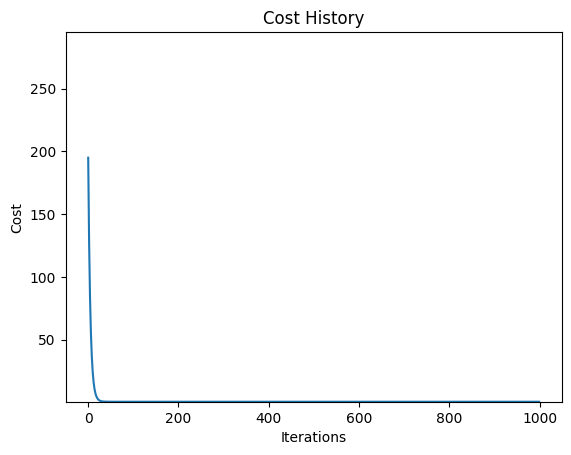

In [327]:
plt.plot(hist)
plt.title("Cost History")
plt.xlabel("Iterations")
plt.ylabel("Cost")
# Zoom in on the last 1000 iterations
plt.ylim(min(hist[-1000:]), max(hist[-1000:]) + 100) 
plt.show()


Predict

In [328]:
def predict(X, w, b):
    return f(X, w, b)

In [329]:
predictions = predict(X_test_scaled, w, b)
predictions[:10]

array([ 4.94590353,  7.55997462,  6.7193651 , 24.65974399, 18.51184777,
       29.10178806, 26.14883512, 23.43656946, 33.07427281,  0.67065498])

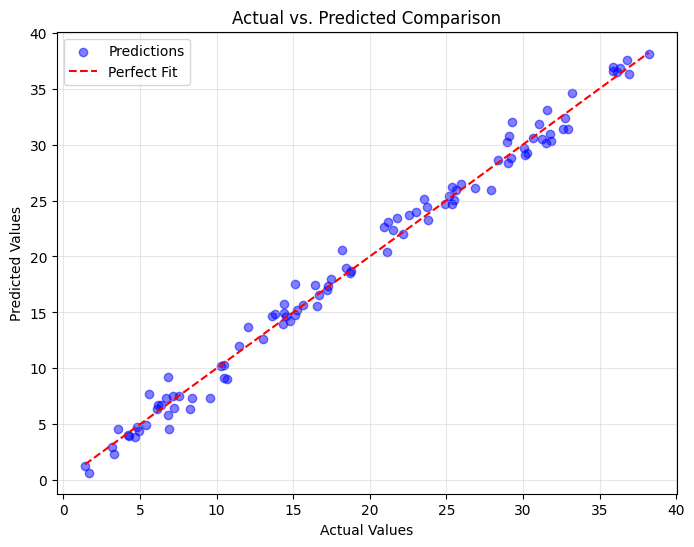

In [330]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue', label='Predictions')

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', label='Perfect Fit')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()